In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [12]:
df = pd.read_csv('pulsar_data_train.csv')

In [13]:
df.columns = df.columns.str.strip()
print("Cleaned Column Names:", df.columns.tolist())

Cleaned Column Names: ['Mean of the integrated profile', 'Standard deviation of the integrated profile', 'Excess kurtosis of the integrated profile', 'Skewness of the integrated profile', 'Mean of the DM-SNR curve', 'Standard deviation of the DM-SNR curve', 'Excess kurtosis of the DM-SNR curve', 'Skewness of the DM-SNR curve', 'target_class']


In [14]:
imputer = SimpleImputer(strategy='mean')
df_filled = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [16]:
class_0 = df_filled[df_filled['target_class'] == 0]
class_1 = df_filled[df_filled['target_class'] == 1]
print(f"Available Class 0: {len(class_0)}")
print(f"Available Class 1: {len(class_1)}")

Available Class 0: 11375
Available Class 1: 1153


In [17]:
sampled_class_0 = class_0.sample(n=1100, random_state=42)
sampled_class_1 = class_1.sample(n=1000, random_state=42)

In [19]:
balanced_df = pd.concat([sampled_class_0, sampled_class_1])
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
print("\nBalanced Class Distribution:")
print(balanced_df['target_class'].value_counts())


Balanced Class Distribution:
0.0    1100
1.0    1000
Name: target_class, dtype: int64


In [20]:
balanced_df.to_csv('pulsar_data_balanced.csv', index=False)

In [21]:
X = balanced_df.drop('target_class', axis=1)
y = balanced_df['target_class']

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [24]:
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [25]:
y_pred = svm_model.predict(X_test)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9333

Confusion Matrix:
[[228   3]
 [ 25 164]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.99      0.94       231
         1.0       0.98      0.87      0.92       189

    accuracy                           0.93       420
   macro avg       0.94      0.93      0.93       420
weighted avg       0.94      0.93      0.93       420



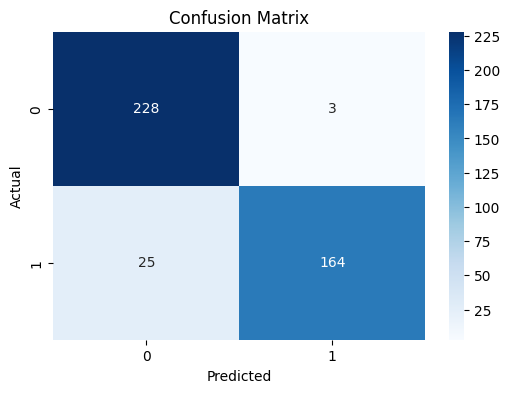

In [28]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()